Customer churn refers to the situation where customers stop using a company’s service or leave the company. In this project, we predict whether a customer will churn or not based on their demographic and service usage information.

why we did this
Predicting churn helps companies identify customers who are likely to leave. Businesses can then take preventive actions such as offering discounts or better service to retain those customers

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [95]:
data = pd.read_csv(r"C:\Users\Smart\Downloads\customer_chrun\WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [96]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [97]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [98]:
data['TotalCharges']

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object

In [99]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

C:\Users\Smart\AppData\Local\Temp\ipykernel_1892\830575513.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


In [100]:
data['AvgCharges'] = data['TotalCharges'] / (data['tenure'] + 1)

In [101]:
#label endoer for the gender and churn
le=LabelEncoder()
data['gender']=le.fit_transform(data['gender'])
data['Churn']=le.fit_transform(data['Churn'])


In [102]:
data.shape

(7043, 22)

In [103]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'AvgCharges'],
      dtype='object')

In [104]:
data.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG       0              0     Yes         No       1   
1     5575-GNVDE       1              0      No         No      34   
2     3668-QPYBK       1              0      No         No       2   
3     7795-CFOCW       1              0      No         No      45   
4     9237-HQITU       0              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB       1              0     Yes        Yes      24   
7039  2234-XADUH       0              0     Yes        Yes      72   
7040  4801-JZAZL       0              0     Yes        Yes      11   
7041  8361-LTMKD       1              1     Yes         No       4   
7042  3186-AJIEK       1              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [105]:
data.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG       0              0     Yes         No       1   
1     5575-GNVDE       1              0      No         No      34   
2     3668-QPYBK       1              0      No         No       2   
3     7795-CFOCW       1              0      No         No      45   
4     9237-HQITU       0              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB       1              0     Yes        Yes      24   
7039  2234-XADUH       0              0     Yes        Yes      72   
7040  4801-JZAZL       0              0     Yes        Yes      11   
7041  8361-LTMKD       1              1     Yes         No       4   
7042  3186-AJIEK       1              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

In [106]:
data['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

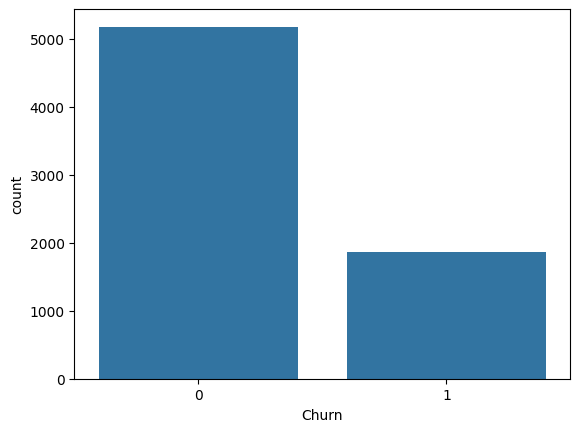

In [107]:
sns.countplot(x='Churn',data=data)
plt.show()

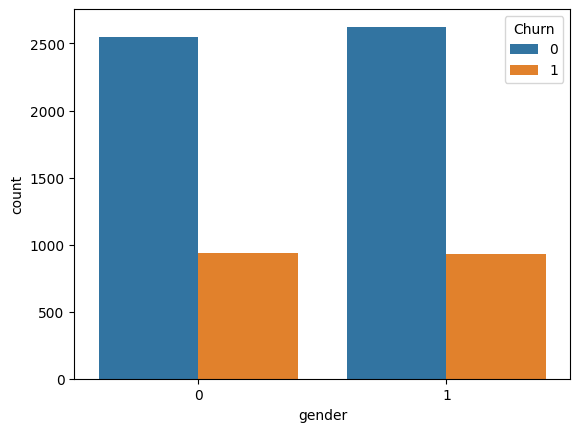

In [108]:
sns.countplot(x='gender',hue='Churn',data=data)
plt.show()

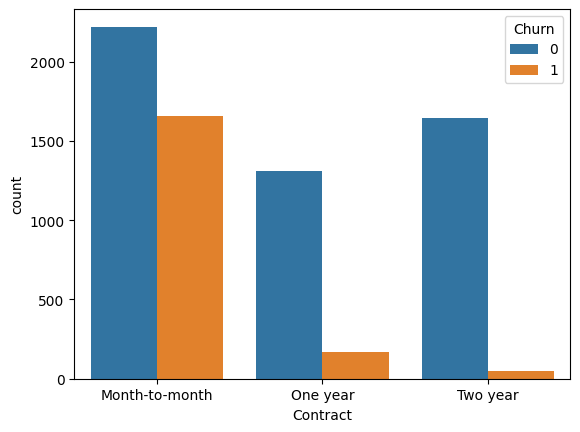

In [109]:
sns.countplot(x='Contract',hue='Churn',data=data)
plt.show()

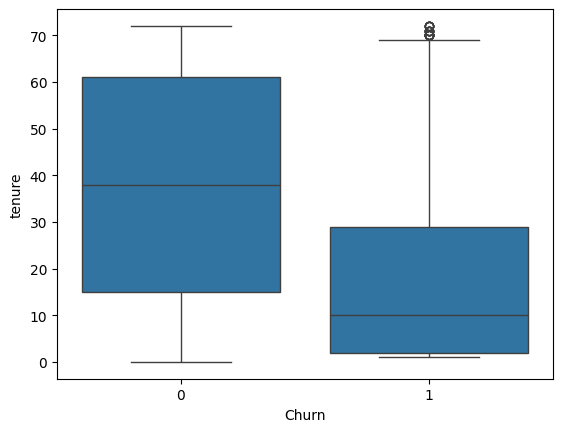

In [110]:
sns.boxplot(x='Churn',y='tenure',data=data)
plt.show()

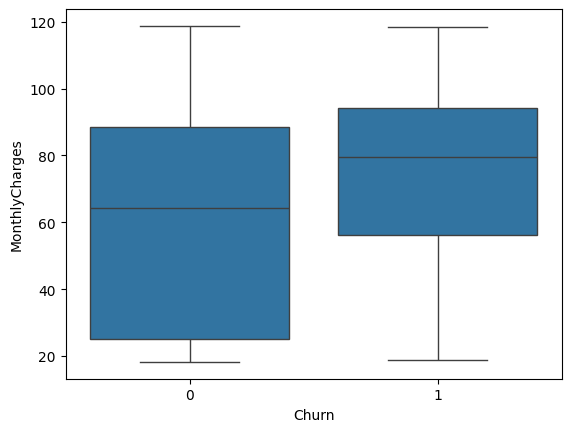

In [111]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=data)
plt.show()

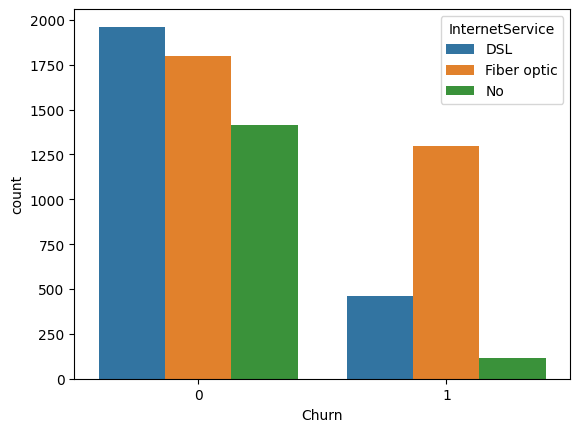

In [112]:
sns.countplot(x='Churn',hue='InternetService',data=data)
plt.show()

In [113]:
data.drop('customerID',axis=1,inplace=True)

In [114]:
data = pd.get_dummies(data, drop_first=True)

In [115]:
X=data.drop('Churn',axis=1)
y=data['Churn']

In [116]:
X.columns

Index(['gender', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgCharges', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing import LabelEncoder


In [118]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [119]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)



c:\Users\Smart\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [120]:
y_pred = model.predict(X_test)

In [121]:
accuracy_score(y_test,y_pred)

0.8140525195173882

In [122]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [123]:
from imblearn.over_sampling import SMOTE

In [124]:
smote=SMOTE(random_state=42)
X_train_res,y_train_res=smote.fit_resample(X_train,y_train)

In [125]:
y_train_res.value_counts()

Churn
0    4138
1    4138
Name: count, dtype: int64

In [126]:
import xgboost as xgb
from xgboost import XGBClassifier

In [127]:
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

In [128]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

,objective,'binary:logistic'
,use_label_encoder,False
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,0.9
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [129]:
y_pred_xgb=xgb_model.predict(X_test)

In [130]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7877927608232789


In [131]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1036
           1       0.59      0.66      0.62       373

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



In [132]:
from sklearn.ensemble import RandomForestClassifier

In [133]:
rfm_model= RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

In [135]:
rfm_model.fit(X_train_res,y_train_res)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [136]:
y_pred_rf=rfm_model.predict(X_test)

In [137]:
print("randomforest accuracy",accuracy_score(y_test,y_pred_rf))

randomforest accuracy 0.794889992902768


In [138]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.82      0.86      1036
           1       0.59      0.71      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409



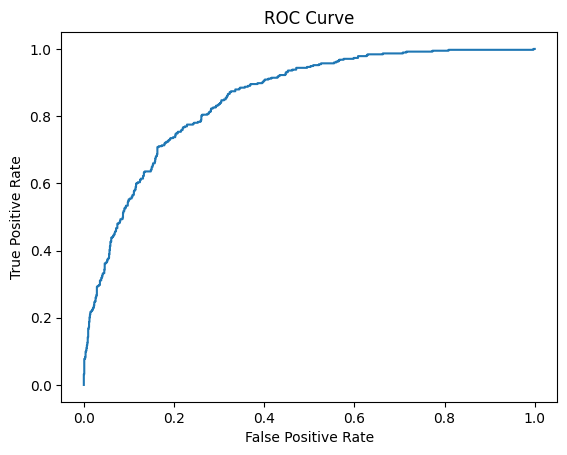

In [140]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rfm_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [141]:
log_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, y_pred_rf)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

results = {
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[log_acc, rf_acc, xgb_acc]
}

import pandas as pd

pd.DataFrame(results)

,Model,Accuracy
0,Logistic Regression,0.814053
1,Random Forest,0.794890
2,XGBoost,0.787793


Logistic Regression achieved higher accuracy because the dataset is relatively small and the relationship between features and churn is close to linear. Logistic Regression is a simpler model that generalizes well with one-hot encoded categorical features, while XGBoost requires more hyperparameter tuning and larger datasets to outperform simpler models

preprocessing steps:

Converted TotalCharges to numeric

Handled missing values

Encoded categorical variables using one-hot encoding

Removed unnecessary columns like customerID

Split the dataset into training and testing sets

Used SMOTE to balance the dataset.

 I built three models: Logistic Regression, Random Forest, and XGBoost. Logistic Regression performed best with about 81% accuracy, meaning the model correctly predicted churn for 81% of customers. This model can help telecom companies identify customers likely to leave and take preventive actions to improve customer retention.